# Detector de estado de frutas y verduras con YOLO entrenado con imagenes de COCO
Esta libreta hace todo el flujo del proyecto:
1. Descarga y prepara el dataset binario Healthy vs Rotten.
2. Entrena un clasificador YOLO11-cls.
3. Evalua en val y test.
4. Ejecuta una prueba automatica con una imagen.
6. Ejecuta inferencia sobre una imagen o una carpeta.

In [2]:
import os
from pathlib import Path

# --- 1. CONFIGURACIÓN DE AMD Y CARPETAS TEMPORALES ---
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "9.0.10" 
os.environ["ROCM_PATH"] = "/opt/rocm"

# Creamos la carpeta temporal en tu espacio
carpeta_tmp = Path.cwd() / ".tmp_miopen"
carpeta_tmp.mkdir(exist_ok=True)

# ¡El truco maestro! Engañamos a Linux y a Boost para que usen tu carpeta
os.environ["TMPDIR"] = str(carpeta_tmp)
os.environ["TEMP"] = str(carpeta_tmp)
os.environ["TMP"] = str(carpeta_tmp)

# Y por si acaso, se lo repetimos a MIOpen
os.environ["MIOPEN_USER_DB_PATH"] = str(carpeta_tmp)
os.environ["MIOPEN_CUSTOM_CACHE_DIR"] = str(carpeta_tmp)

In [3]:
import random
import shutil
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
import cv2 
import matplotlib.pyplot as plt
import pandas as pd
import torch
import mlflow
from tqdm.auto import tqdm
from ultralytics import YOLO
import kagglehub

DATASET_SLUG = "muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten"
DATA_DIR = Path.cwd() / "fruit_binary_yolo_cls"
BASE_MODEL = "yolo11n-cls.pt"
TRAIN_RUN_NAME = "fruit_hs_vs_rt_cls_simple_ft5"
DETECTOR_WEIGHTS = "yolo11n.pt"
CLASSIFIER_WEIGHTS = Path("runs/classify") / TRAIN_RUN_NAME / "weights" / "best.pt"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
PRODUCE_CLASS_NAMES = {"apple", "banana", "orange", "broccoli", "carrot"}


if torch.cuda.is_available():
    # En sistemas AMD con ROCm, esto devolverá True
    DEVICE = 0 
    print(f"Usando GPU AMD/NVIDIA: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    # Por si alguna vez programas en una Mac con chip M1/M2/M3
    DEVICE = "mps"
    print("Usando Apple Metal (MPS)")
else:
    DEVICE = "cpu"
    print("Usando CPU (No se detectó GPU compatible)")

print("Data dir:", DATA_DIR)
print("Base model:", BASE_MODEL)
print("Run name:", TRAIN_RUN_NAME)

Usando GPU AMD/NVIDIA: AMD Instinct MI210
Data dir: /lustre/cursos/curso04/estudiante_66/computerVision/fruit_binary_yolo_cls
Base model: yolo11n-cls.pt
Run name: fruit_hs_vs_rt_cls_simple_ft5


## Preparación del dataset binario

Convertimos el dataset original (organizado por fruta y estado: `Apple_Healthy`, `Apple_Rotten`, …) en **dos clases únicas**: `Healthy` y `Rotten`. Aplicamos un *split estratificado* 80 / 10 / 10 (train / val / test) y usamos `os.link` cuando el sistema lo permite para no duplicar en disco las ~29 000 imágenes.

In [3]:
def find_dataset_root(download_path):
    candidates = [download_path] + [path for path in download_path.iterdir() if path.is_dir()]
    for candidate in candidates:
        subdirs = [path.name for path in candidate.iterdir() if path.is_dir()]
        has_healthy = any(name.endswith("_Healthy") for name in subdirs)
        has_rotten = any(name.endswith("_Rotten") for name in subdirs)
        if has_healthy and has_rotten:
            return candidate
    raise FileNotFoundError("No se encontro una carpeta con estructura *_Healthy / *_Rotten")

def collect_images(dataset_root):
    grouped_paths = defaultdict(list)
    for class_dir in sorted(path for path in dataset_root.iterdir() if path.is_dir()):
        name = class_dir.name
        if name.endswith("_Healthy"):
            label = "Healthy"
        elif name.endswith("_Rotten"):
            label = "Rotten"
        else:
            continue

        files = [path for path in class_dir.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTS]
        grouped_paths[label].extend(files)
    return grouped_paths

def stratified_split(items_by_label, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
    rng = random.Random(seed)

    split = {
        "train": defaultdict(list),
        "val": defaultdict(list),
        "test": defaultdict(list),
    }

    for label, items in items_by_label.items():
        items = items.copy()
        rng.shuffle(items)

        count = len(items)
        count_train = int(count * train_ratio)
        count_val = int(count * val_ratio)

        split["train"][label] = items[:count_train]
        split["val"][label] = items[count_train:count_train + count_val]
        split["test"][label] = items[count_train + count_val:]

    return split

def count_images(root):
    summary = {}
    for split_name in ["train", "val", "test"]:
        summary[split_name] = {}
        for label in ["Healthy", "Rotten"]:
            label_dir = root / split_name / label
            if label_dir.exists():
                count = len([path for path in label_dir.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTS])
                summary[split_name][label] = count
            else:
                summary[split_name][label] = 0
    return summary

def link_or_copy(src, dst):
    try:
        os.link(src, dst)
    except OSError:
        shutil.copy2(src, dst)

# 5. Función Principal de Preparación de Datos
def build_binary_dataset(output_root=DATA_DIR):
    # Lógica de guarda: Si la carpeta train existe, no descargamos de nuevo
    if output_root.exists() and (output_root / "train").exists():
        print(f"El dataset ya existe en {output_root.name}. Saltando descarga.")
        return count_images(output_root)

    print("Preparando dataset...")
    raw_download_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    dataset_root = find_dataset_root(raw_download_path)
    grouped_paths = collect_images(dataset_root)
    splits = stratified_split(grouped_paths, seed=SEED)

    if output_root.exists():
        shutil.rmtree(output_root)

    for split_name in ["train", "val", "test"]:
        for label in ["Healthy", "Rotten"]:
            (output_root / split_name / label).mkdir(parents=True, exist_ok=True)

    jobs = []
    for split_name, split_labels in splits.items():
        for label, paths in split_labels.items():
            out_dir = output_root / split_name / label
            for index, src in enumerate(paths):
                dst = out_dir / f"{label.lower()}_{index:07d}{src.suffix.lower()}"
                jobs.append((src, dst))

    with ThreadPoolExecutor(max_workers=min(16, os.cpu_count() or 8)) as executor:
        list(tqdm(executor.map(lambda item: link_or_copy(*item), jobs), total=len(jobs), desc="Preparando dataset"))

    return count_images(output_root)

def choose_sample_image(test_root=DATA_DIR / "test"):
    for label in ["Healthy", "Rotten"]:
        label_dir = test_root / label
        if not label_dir.exists():
            continue
        for path in sorted(label_dir.glob("*")):
            if path.suffix.lower() in IMAGE_EXTS:
                return path
    raise FileNotFoundError("No se encontro una imagen de prueba en DATA_DIR/test")

def metrics_to_dataframe(split_name, metrics):
    rows = []
    results_dict = getattr(metrics, "results_dict", {}) or {}
    for key, value in results_dict.items():
        if isinstance(value, (int, float)):
            rows.append({
                "split": split_name,
                "metric": key,
                "value": float(value),
            })
    return pd.DataFrame(rows)

# 6. Ejecutamos la validación/creación del dataset
resumen_dataset = build_binary_dataset()

print("\n--- Resumen de Imágenes ---")
for split, labels in resumen_dataset.items():
    print(f"[{split.upper()}] Sanas: {labels.get('Healthy', 0)} | Podridas: {labels.get('Rotten', 0)}")

El dataset ya existe en fruit_binary_yolo_cls. Saltando descarga.

--- Resumen de Imágenes ---
[TRAIN] Sanas: 11029 | Podridas: 12403
[VAL] Sanas: 1378 | Podridas: 1550
[TEST] Sanas: 1380 | Podridas: 1551


In [4]:
dataset_summary = build_binary_dataset()
dataset_summary

El dataset ya existe en fruit_binary_yolo_cls. Saltando descarga.


{'train': {'Healthy': 11029, 'Rotten': 12403},
 'val': {'Healthy': 1378, 'Rotten': 1550},
 'test': {'Healthy': 1380, 'Rotten': 1551}}

## Entrenamiento del clasificador YOLOv11-cls

*Fine-tuning* corto sobre el checkpoint pre-entrenado `yolo11n-cls.pt` (nano, ~1.5 M parámetros) con `freeze=10`: congelamos las primeras capas y sólo ajustamos la cabeza de clasificación.  El bloque abre una corrida de MLflow, entrena y sube `best.pt` como artefacto.



In [5]:


# 1. DEFINICIÓN DE RUTAS (Ruta absoluta de Lustre)
# Usamos la que me confirmaste donde estás trabajando
RUTA_PROYECTO = Path("/lustre/home/estudiante_66/computerVision/computerVision")
RUTA_MLRUNS = RUTA_PROYECTO / "mlruns"

# Configuración de MLflow
mlflow.set_tracking_uri(f"file://{RUTA_MLRUNS}")
mlflow.set_experiment("Clasificacion_Frutas_Sanas_vs_Podridas")

print(f" Proyecto en: {RUTA_PROYECTO}")
print(f" Registros en: {RUTA_MLRUNS}")

# 2. INICIO DEL ENTRENAMIENTO
# Usamos el bloque 'with' para asegurar que la corrida se cierre correctamente
with mlflow.start_run(run_name=TRAIN_RUN_NAME) as run:
    
    # Cargamos el modelo base
    model = YOLO(BASE_MODEL)
    
    # Entrenamiento
    # Nota: 'project' ahora apunta a tu carpeta de Lustre directamente
    model.train(
        data=str(DATA_DIR),
        task="classify",
        imgsz=640,
        epochs=5,
        batch=32,
        device=DEVICE,
        project=str(RUTA_PROYECTO / "runs"), # Se guardará en /computerVision/runs
        name=TRAIN_RUN_NAME,
        pretrained=True,
        deterministic=True,
        verbose=True,
        workers=0,
        exist_ok=True,
        freeze=10
    )

    # 3. VALIDACIÓN Y GUARDADO DE ARTEFACTOS
    # En lugar de armar la ruta a mano, se la pedimos a YOLO
    if hasattr(model, 'trainer') and model.trainer is not None:
        directorio_entrenamiento = Path(model.trainer.save_dir)
        best_weights = directorio_entrenamiento / "weights" / "best.pt"
    else:
        # Respaldo manual si el objeto no tiene el atributo
        best_weights = RUTA_PROYECTO / "runs" / TRAIN_RUN_NAME / "weights" / "best.pt"

    # Verificación de seguridad
    if best_weights.exists():
        print(f" Pesos localizados en: {best_weights}")
        # Subimos el mejor modelo como artefacto a MLflow
        mlflow.log_artifact(str(best_weights), artifact_path="modelo_final_yolo")
        print(" ¡Modelo y métricas guardados exitosamente en MLflow!")
    else:
        print(f" Error: No se encontró best.pt en {best_weights}")
        # Listamos contenido para debug si llega a fallar
        print("Contenido de la carpeta de entrenamiento:")
        !ls -R {str(RUTA_PROYECTO / "runs")}

 Proyecto en: /lustre/home/estudiante_66/computerVision/computerVision
 Registros en: /lustre/home/estudiante_66/computerVision/computerVision/mlruns
Ultralytics 8.4.24 🚀 Python-3.9.21 torch-2.3.1+rocm5.7 CUDA:0 (AMD Instinct MI210, 65520MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/lustre/cursos/curso04/estudiante_66/computerVision/fruit_binary_yolo_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.

2026/03/25 17:51:21 INFO mlflow.tracking.fluent: Experiment with name '/lustre/home/estudiante_66/computerVision/computerVision/runs' does not exist. Creating a new experiment.


MLflow: logging run_id(95aa7a1c92bc412ab881c98ef4fe7d68) to file:///lustre/home/estudiante_66/computerVision/computerVision/mlruns
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /lustre/cursos/curso04/estudiante_66/computerVision/runs/fruit_hs_vs_rt_cls_simple_ft5
Starting training for 5 epochs...

      Epoch    GPU_mem       loss  Instances       Size
        1/5     0.104G     0.2946          8        640: 100% ━━━━━━━━━━━━ 733/733 1.0it/s 11:50<0.5s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 46/46 1.4s/it 1:061.5sss
                   all       0.96          1

      Epoch    GPU_mem       loss  Instances       Size
        2/5     0.787G     0.1651          8        640: 100% ━━━━━━━━━━━━ 733/733 1.5it/s 8:13<0.4s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 46/46 1.2it/s 39.9s0.9ss
                   all      0.973          1

      Epoch    GPU_mem       loss  

In [7]:
# 1. Apuntamos a la ruta real de Lustre
ruta_maestra = "/lustre/cursos/curso04/estudiante_66/computerVision/mlruns"
mlflow.set_tracking_uri(f"file://{ruta_maestra}")

# 2. Fijamos el nombre que TÚ quieres ver en la interfaz
mlflow.set_experiment("Clasificacion_Frutas_Sanas_vs_Podridas")

best_weights = Path("runs/classify/runs/classify/fruit_hs_vs_rt_cls_simple_ft5/weights/best.pt")

if best_weights.exists():
    # Creamos una "corrida" manual para subir los archivos
    with mlflow.start_run(run_name="Rescate_Modelo_Entrenado"):
        # Subimos el archivo .pt
        mlflow.log_artifact(str(best_weights), artifact_path="modelo_final_yolo")
        
        # Si tienes las métricas del DF de arriba, las podemos subir también:
        mlflow.log_param("status", "recuperado_manualmente")
        
        print(f" ¡RESCASTE EXITOSO!")
        print(f"Ahora en MLflow verás el experimento '{mlflow.get_experiment_by_name('Clasificacion_Frutas_Sanas_vs_Podridas').name}'")
else:
    print(f" Seguimos sin ver el archivo en {best_weights}")
    print("Corre esto para encontrarlo de una vez: !find runs -name 'best.pt'")

✅ ¡RESCASTE EXITOSO!
Ahora en MLflow verás el experimento 'Clasificacion_Frutas_Sanas_vs_Podridas'


## Refactor: Evaluación + MLflow con pesos ya entrenados

Bloque modular pensado para ejecutarse **sin reentrenar**. Sólo edita las rutas en la celda de configuración para alternar entre Windows y la ruta de Lustre en el clúster.

**Flujo:**
1. Configuración de rutas, hiperparámetros y validación de artefactos.
2. Carga de `best.pt` y evaluación explícita sobre TEST (Top-1, Top-5, matriz de confusión, gráficas).
3. Registro robusto en MLflow (parámetros, métricas y artefactos `.pt` + plots).
4. Inferencia demostrativa sobre 5 imágenes aleatorias del test.

**Nota sobre gráficas:** para tareas `classify`, YOLO genera únicamente `confusion_matrix.png` y `confusion_matrix_normalized.png`. Las curvas F1 / PR son propias de tareas de detección y no se generarán en este flujo; el código las detecta opcionalmente si existieran.

In [4]:

# --- RUTAS EDITABLES (cambia aqui cuando pases Windows <-> Lustre) --------
PATH_BEST_WEIGHTS = Path("/lustre/home/estudiante_66/computerVision/computerVision/runs/classify/runs/classify/fruit_hs_vs_rt_cls_simple_ft5/weights/best.pt")
PATH_DATA         = Path(DATA_DIR)      # reutiliza DATA_DIR definido arriba
PATH_MLRUNS       = Path("/lustre/home/estudiante_66/computerVision/computerVision/mlruns")     
MLFLOW_EXPERIMENT = "Clasificacion_Frutas_Sanas_vs_Podridas"

# --- HIPERPARAMETROS DE INFERENCIA (trazabilidad en MLflow) ---------------
EVAL_IMGSZ = 640
EVAL_BATCH = 32
EVAL_CONF  = 0.25  
EVAL_IOU   = 0.60

# --- VALIDACION DE ARCHIVO[S ANTES DE CONTINUAR ----------------------------
def _build_tracking_uri(path: Path) -> str:
    """Genera un URI file:// multiplataforma (Windows y Linux)."""
    path = path.resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path.as_uri() 

if not PATH_BEST_WEIGHTS.exists():
    raise FileNotFoundError(
        f"No se encontro best.pt en: {PATH_BEST_WEIGHTS}\n"
        "Edita PATH_BEST_WEIGHTS con la ruta correcta."
    )
if not PATH_DATA.exists():
    raise FileNotFoundError(f"No se encontro el dataset en: {PATH_DATA}")

MLFLOW_TRACKING_URI = _build_tracking_uri(PATH_MLRUNS)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# Desactiva el autolog de Ultralytics para que no cree runs paralelos
# al ejecutar model.val(); si lo quieres activo ponlo en True.
try:
    from ultralytics import settings as _ul_settings
    _ul_settings.update({"mlflow": False})
except Exception:
    pass

print(f"Pesos      : {PATH_BEST_WEIGHTS}")
print(f"Dataset    : {PATH_DATA}")
print(f"MLflow URI : {MLFLOW_TRACKING_URI}")
print(f"Experimento: {MLFLOW_EXPERIMENT}")

# --- CARGA DEL MODELO DESDE LOS PESOS -------------------------------------
model = YOLO(str(PATH_BEST_WEIGHTS))
CLASS_NAMES = list(model.names.values()) if isinstance(model.names, dict) else list(model.names)
print(f"Modelo cargado | clases: {CLASS_NAMES}")


Pesos      : /lustre/home/estudiante_66/computerVision/computerVision/runs/classify/runs/classify/fruit_hs_vs_rt_cls_simple_ft5/weights/best.pt
Dataset    : /lustre/cursos/curso04/estudiante_66/computerVision/fruit_binary_yolo_cls
MLflow URI : file:///lustre/cursos/curso04/estudiante_66/computerVision/mlruns
Experimento: Clasificacion_Frutas_Sanas_vs_Podridas
Modelo cargado | clases: ['Healthy', 'Rotten']


In [5]:

# Evaluacion sobre TEST con extraccion explicita de metricas y artefactos.
import numpy as np

test_metrics = model.val(
    data=str(PATH_DATA),
    split="test",
    imgsz=EVAL_IMGSZ,
    batch=EVAL_BATCH,
    device=DEVICE,
    workers=2,          # Yuca sugiere max 2: evita warning de DataLoader
    plots=True,
    verbose=False,
)

# --- Metricas escalares ----------------------------------------------------
results_dict = getattr(test_metrics, "results_dict", {}) or {}
top1 = float(results_dict.get("metrics/accuracy_top1", float("nan")))
top5 = float(results_dict.get("metrics/accuracy_top5", float("nan")))
fitness = float(results_dict.get("fitness", float("nan")))

# --- Matriz de confusion ---------------------------------------------------
cm_matrix = None
if getattr(test_metrics, "confusion_matrix", None) is not None:
    cm_matrix = np.asarray(test_metrics.confusion_matrix.matrix)

# --- Graficas generadas por YOLO en save_dir -------------------------------
# Nota: para task="classify" YOLO NO genera F1_curve/PR_curve;
# solo confusion_matrix(_normalized). Se contemplan por compatibilidad.
eval_save_dir = Path(test_metrics.save_dir) if hasattr(test_metrics, "save_dir") else None
plot_files = {}
if eval_save_dir and eval_save_dir.exists():
    candidatos = [
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "F1_curve.png",
        "PR_curve.png",
        "P_curve.png",
        "R_curve.png",
        "results.png",
    ]
    for nombre in candidatos:
        ruta = eval_save_dir / nombre
        if ruta.exists():
            plot_files[nombre] = ruta

metrics_summary = pd.DataFrame([
    {"metric": "accuracy_top1", "value": top1},
    {"metric": "accuracy_top5", "value": top5},
    {"metric": "fitness",       "value": fitness},
])

print("--- Metricas en TEST ---")
print(metrics_summary.to_string(index=False))
print(f"\nMatriz de confusion:\n{cm_matrix}")
print(f"\nArtefactos generados en: {eval_save_dir}")
for nombre, ruta in plot_files.items():
    print(f"  - {nombre} -> {ruta}")


Ultralytics 8.4.24 🚀 Python-3.9.21 torch-2.3.1+rocm5.7 CUDA:0 (AMD Instinct MI210, 65520MiB)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /lustre/cursos/curso04/estudiante_66/computerVision/fruit_binary_yolo_cls/train... found 23432 images in 2 classes ✅ 
val: /lustre/cursos/curso04/estudiante_66/computerVision/fruit_binary_yolo_cls/val... found 2928 images in 2 classes ✅ 
test: /lustre/cursos/curso04/estudiante_66/computerVision/fruit_binary_yolo_cls/test... found 2931 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.2±0.0 ms, read: 161.2±143.7 MB/s, size: 98.2 KB)
test: Scanning /lustre/cursos/curso04/estudiante_66/computerVision/fruit_binary_yolo_cls/test... 2931 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2931/2931 558.8Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 92/92 3.5it/s 26.5s0.3ss
                   all       0.99          1
Speed: 0.2ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess

In [6]:
# Bloque robusto de MLflow: registra parametros, metricas y artefactos
# en una corrida independiente. Cada ejecucion crea un nuevo run_name.
import tempfile
from typing import Optional

def log_evaluation_to_mlflow(
    run_name: str = "eval_test_best_pt",
    extra_params: Optional[dict] = None,
) -> str:
    params = {
        "weights_path": str(PATH_BEST_WEIGHTS),
        "data_path":    str(PATH_DATA),
        "imgsz":        EVAL_IMGSZ,
        "batch":        EVAL_BATCH,
        "conf":         EVAL_CONF,
        "iou":          EVAL_IOU,
        "device":       str(DEVICE),
        "split":        "test",
        "num_classes":  len(CLASS_NAMES),
        "task":         "classify",
    }
    if extra_params:
        params.update(extra_params)

    metrics = {
        "accuracy_top1": top1,
        "accuracy_top5": top5,
        "fitness":       fitness,
    }

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)
        mlflow.log_metrics({k: v for k, v in metrics.items() if not np.isnan(v)})
        mlflow.set_tag("classes", ",".join(CLASS_NAMES))

        mlflow.log_artifact(str(PATH_BEST_WEIGHTS), artifact_path="modelo")

        for name, path in plot_files.items():
            try:
                mlflow.log_artifact(str(path), artifact_path="plots")
            except Exception as exc:
                print(f"  [WARN] No se pudo subir {name}: {exc}")

        if cm_matrix is not None:
            n_rows = cm_matrix.shape[0]
            if n_rows == len(CLASS_NAMES):
                cm_labels = list(CLASS_NAMES)
            elif n_rows == len(CLASS_NAMES) + 1:
                cm_labels = list(CLASS_NAMES) + ["background"]
            else:
                cm_labels = [f"class_{i}" for i in range(n_rows)]

            cm_df = pd.DataFrame(
                cm_matrix,
                index=[f"true_{c}" for c in cm_labels],
                columns=[f"pred_{c}" for c in cm_labels],
            )
            with tempfile.TemporaryDirectory() as tmp:
                cm_csv = Path(tmp) / "confusion_matrix.csv"
                cm_df.to_csv(cm_csv)
                mlflow.log_artifact(str(cm_csv), artifact_path="plots")

        with tempfile.TemporaryDirectory() as tmp:
            metrics_csv = Path(tmp) / "metrics_test.csv"
            metrics_summary.to_csv(metrics_csv, index=False)
            mlflow.log_artifact(str(metrics_csv), artifact_path="metrics")

        print(f"MLflow run creado | run_id = {run.info.run_id}")
        return run.info.run_id

run_id = log_evaluation_to_mlflow()
print(f"URI activo: {mlflow.get_tracking_uri()}")



MLflow run creado | run_id = f52bf2633c6647789a5b3ed364c54e6f
URI activo: file:///lustre/cursos/curso04/estudiante_66/computerVision/mlruns


## Usamos imagenes de test para clasificar

Imagenes disponibles en /lustre/cursos/curso04/estudiante_66/computerVision/fruit_binary_yolo_cls/test: 2931
Figura guardada en: /lustre/cursos/curso04/estudiante_66/computerVision/inferencia_conteo.png


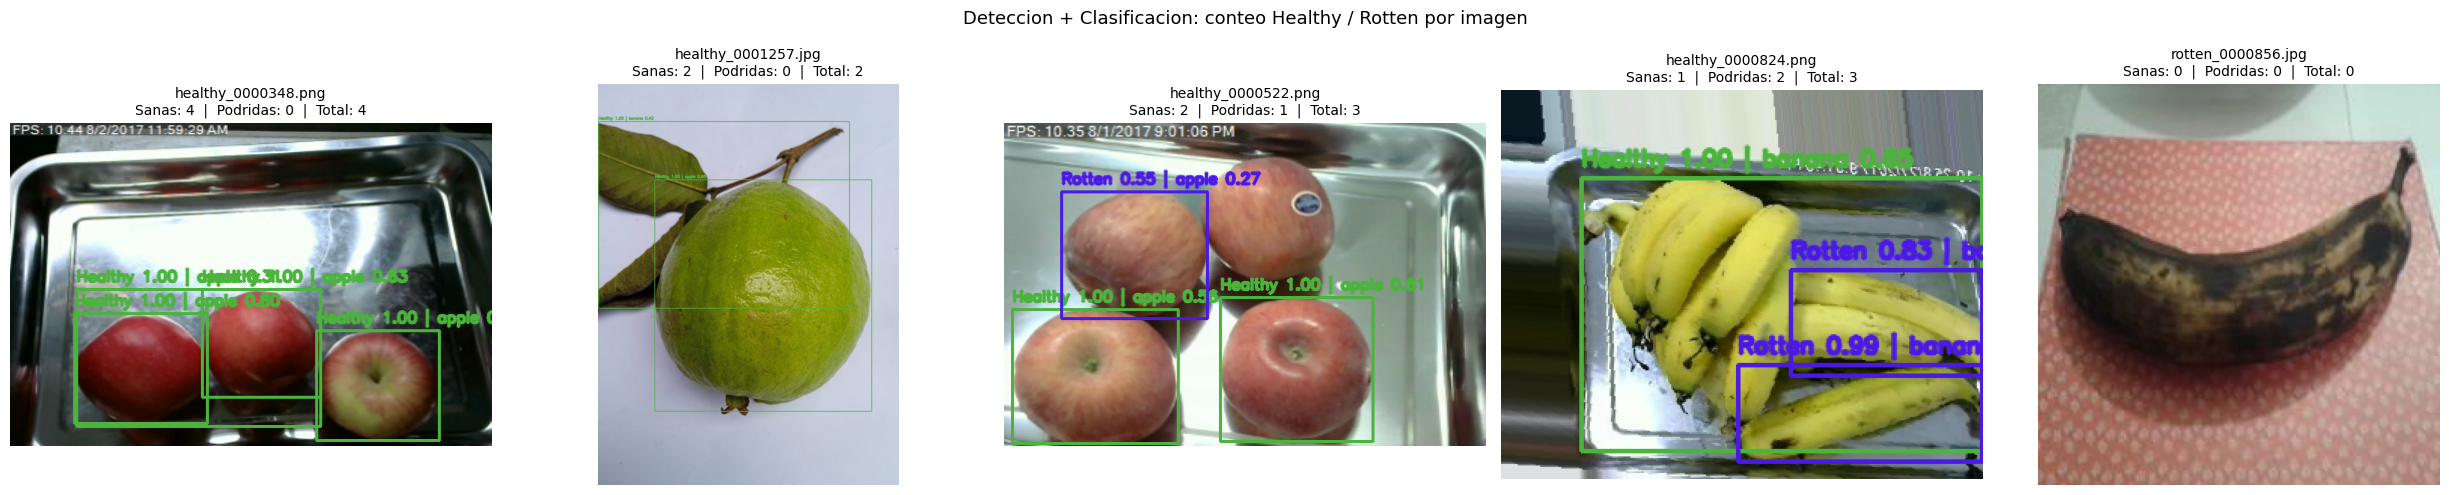


--- Resumen de conteos ---


,imagen,sanas,podridas,total
0,healthy_0000348.png,4,0,4
1,healthy_0001257.jpg,2,0,2
2,healthy_0000522.png,2,1,3
3,healthy_0000824.png,1,2,3
4,rotten_0000856.jpg,0,0,0


In [17]:
%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

import gc
import random as _random
import cv2
from IPython.display import display

NUM_SAMPLES = 5
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# --- Config detector + clasificador ---------------------------------------
DETECTOR_WEIGHTS_LOCAL = globals().get("DETECTOR_WEIGHTS", "yolo11n.pt")
PRODUCE_CLASSES        = globals().get(
    "PRODUCE_CLASS_NAMES",
    {"apple", "banana", "orange", "broccoli", "carrot"},
)

if "detector" not in globals():
    detector = YOLO(DETECTOR_WEIGHTS_LOCAL)
if "classifier" not in globals():
    classifier = YOLO(str(PATH_BEST_WEIGHTS))

# --- Pipeline: detectar frutas -> clasificar cada crop -> contar ----------
def _clamp_box(x1, y1, x2, y2, width, height):
    x1 = max(0, min(int(x1), width - 1))
    y1 = max(0, min(int(y1), height - 1))
    x2 = max(0, min(int(x2), width - 1))
    y2 = max(0, min(int(y2), height - 1))
    if x2 <= x1:
        x2 = min(width - 1, x1 + 1)
    if y2 <= y1:
        y2 = min(height - 1, y1 + 1)
    return x1, y1, x2, y2

def _detect_and_count(image_path, det_conf=0.20, det_iou=0.60,
                      min_box_area=32 * 32, only_produce=True):
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise FileNotFoundError(f"No se pudo leer imagen: {image_path}")
    height, width = bgr.shape[:2]

    det = detector.predict(source=bgr, conf=det_conf, iou=det_iou,
                           device=DEVICE, verbose=False)[0]
    healthy = rotten = 0
    for box in det.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        x1, y1, x2, y2 = _clamp_box(x1, y1, x2, y2, width, height)
        if (x2 - x1) * (y2 - y1) < min_box_area:
            continue

        det_name = det.names[int(box.cls[0].item())]
        det_score = float(box.conf[0].item())
        if only_produce and det_name not in PRODUCE_CLASSES:
            continue

        crop = bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        cls_r = classifier.predict(source=crop, imgsz=EVAL_IMGSZ,
                                   device=DEVICE, verbose=False)[0]
        label = cls_r.names[int(cls_r.probs.top1)]
        conf  = float(cls_r.probs.top1conf.item())

        if "healthy" in label.lower():
            healthy += 1
            color = (60, 180, 75)
        elif "rotten" in label.lower():
            rotten += 1
            color = (230, 25, 75)
        else:
            color = (255, 165, 0)

        cv2.rectangle(bgr, (x1, y1), (x2, y2), color, 2)
        cv2.putText(bgr, f"{label} {conf:.2f} | {det_name} {det_score:.2f}",
                    (x1, max(20, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)

    return bgr, {"healthy": healthy, "rotten": rotten,
                 "total": healthy + rotten}

# --- Seleccion de imagenes ------------------------------------------------
INFERENCE_DIR = Path("inference_images")
TEST_DIR      = PATH_DATA / "test"

def _list_images(folder: Path):
    return [p for p in folder.rglob("*")
            if p.is_file() and p.suffix.lower() in IMG_EXTS]

source_dir = INFERENCE_DIR if (INFERENCE_DIR.exists() and _list_images(INFERENCE_DIR)) else TEST_DIR
all_images = _list_images(source_dir)
if not all_images:
    raise FileNotFoundError(f"No hay imagenes en {source_dir}")

print(f"Imagenes disponibles en {source_dir}: {len(all_images)}")

num = min(NUM_SAMPLES, len(all_images))
sample_paths = _random.Random().sample(all_images, num)

# --- Inferencia + visualizacion ------------------------------------------
fig, axes = plt.subplots(1, num, figsize=(5 * num, 5))
if num == 1:
    axes = [axes]

rows = []
with torch.inference_mode():
    for ax, img_path in zip(axes, sample_paths):
        annotated_bgr, summary = _detect_and_count(
            img_path, det_conf=0.20, det_iou=0.60,
            min_box_area=32 * 32, only_produce=True,
        )
        ax.imshow(cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(
            f"{img_path.name}\n"
            f"Sanas: {summary['healthy']}  |  "
            f"Podridas: {summary['rotten']}  |  "
            f"Total: {summary['total']}",
            fontsize=10,
        )
        ax.axis("off")

        rows.append({
            "imagen":   img_path.name,
            "sanas":    summary["healthy"],
            "podridas": summary["rotten"],
            "total":    summary["total"],
        })

fig.suptitle("Deteccion + Clasificacion: conteo Healthy / Rotten por imagen",
             fontsize=13)
fig.tight_layout()

out_png = Path("inferencia_conteo.png")
fig.savefig(out_png, dpi=120, bbox_inches="tight")
print(f"Figura guardada en: {out_png.resolve()}")

display(fig)
plt.close(fig)

df_conteo = pd.DataFrame(rows)
print("\n--- Resumen de conteos ---")
display(df_conteo)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## aqui vemos que no detecta algunos objetos por lo que no tiene mucho sentido las metricas que aparecen a continuacuin

## Métricas : Precision / Recall / F1 + curvas ROC y PR

Accuracy global es una métrica engañosa cuando importa saber **qué tipo de error** domina. Estas dos celdas complementan la evaluación:

1. **Precision, Recall y F1 por clase** — desglosa dónde falla el modelo (por ejemplo, si confunde más podridas como sanas —*falsos negativos de defecto*— que al revés).
2. **Curva ROC + AUC y curva Precision-Recall + AP** — miden el desempeño en **todos los umbrales de decisión**, no sólo en el 0.5 por defecto. Útiles si vas a desplegar con un umbral custom (por ejemplo, priorizando recall para no dejar pasar frutas podridas).

Imagenes en test: 2931 | batch=16


Inferencia test (batched):   0%|          | 0/184 [00:00<?, ?it/s]

/lustre/cursos/curso04/estudiante_66/computerVision/.venv/lib64/python3.9/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



--- classification_report ---
              precision    recall  f1-score   support

     Healthy     0.9906    0.9891    0.9898      1380
      Rotten     0.9903    0.9916    0.9910      1551

    accuracy                         0.9904      2931
   macro avg     0.9905    0.9904    0.9904      2931
weighted avg     0.9904    0.9904    0.9904      2931

--- Metricas por clase ---


,Precision,Recall,F1,Support
Healthy,0.9906,0.9891,0.9898,1380
Rotten,0.9903,0.9916,0.9910,1551


Figura guardada en: /lustre/cursos/curso04/estudiante_66/computerVision/per_class_metrics.png


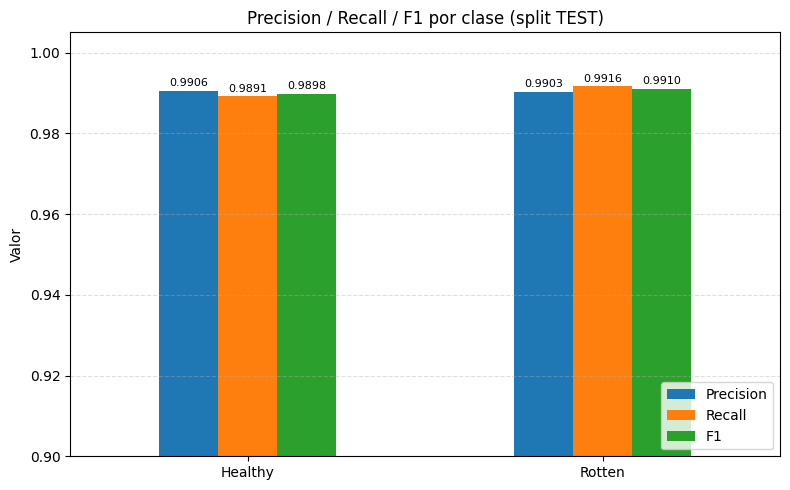

In [15]:
%matplotlib inline
from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
)
from tqdm.auto import tqdm
from IPython.display import display
import numpy as np
import gc

BATCH_SIZE = 16

label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
POS_CLASS_IDX = label_to_idx.get("Rotten", 1)

test_images = []
y_true_list = []
for class_name in CLASS_NAMES:
    class_dir = PATH_DATA / "test" / class_name
    if not class_dir.exists():
        continue
    for p in sorted(class_dir.rglob("*")):
        if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
            test_images.append(str(p))
            y_true_list.append(label_to_idx[class_name])

y_true = np.asarray(y_true_list, dtype=int)
print(f"Imagenes en test: {len(test_images)} | batch={BATCH_SIZE}")

y_pred  = np.zeros(len(test_images), dtype=int)
y_proba = np.zeros(len(test_images), dtype=float)

# Batches pequenos + liberacion de GPU tras cada lote para no saturar VRAM.
for start in tqdm(range(0, len(test_images), BATCH_SIZE),
                  desc="Inferencia test (batched)"):
    chunk = test_images[start:start + BATCH_SIZE]

    with torch.inference_mode():
        results = model.predict(
            source=chunk,
            imgsz=EVAL_IMGSZ,
            device=DEVICE,
            verbose=False,
            stream=False,
        )

    for j, r in enumerate(results):
        probs_np = r.probs.data.detach().cpu().numpy()
        y_pred[start + j]  = int(np.argmax(probs_np))
        y_proba[start + j] = float(probs_np[POS_CLASS_IDX])

    del results
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(CLASS_NAMES))), zero_division=0
)

df_pcm = pd.DataFrame({
    "Precision": precision,
    "Recall":    recall,
    "F1":        f1,
    "Support":   support,
}, index=CLASS_NAMES)

print("\n--- classification_report ---")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                            digits=4, zero_division=0))

print("--- Metricas por clase ---")
display(df_pcm.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
df_pcm[["Precision", "Recall", "F1"]].plot(kind="bar", ax=ax,
                                           color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_title("Precision / Recall / F1 por clase (split TEST)")
ax.set_ylabel("Valor")
ax.set_ylim(min(0.9, df_pcm[["Precision", "Recall", "F1"]].min().min() - 0.01), 1.005)
ax.set_xticklabels(CLASS_NAMES, rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=2, fontsize=8)
fig.tight_layout()

out_png = Path("per_class_metrics.png")
fig.savefig(out_png, dpi=120, bbox_inches="tight")
print(f"Figura guardada en: {out_png.resolve()}")

display(fig)
plt.close(fig)

Figura guardada en: /lustre/cursos/curso04/estudiante_66/computerVision/roc_pr_curves.png


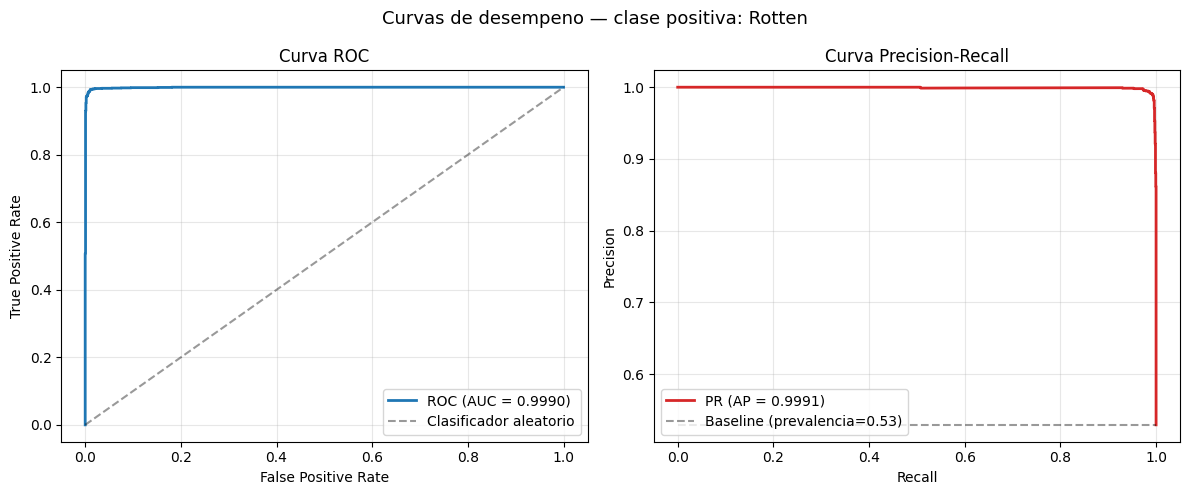


ROC AUC            = 0.9990
Average Precision  = 0.9991


In [16]:
%matplotlib inline
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from IPython.display import display

y_true_bin = (y_true == POS_CLASS_IDX).astype(int)

fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
roc_auc = auc(fpr, tpr)

precision_pr, recall_pr, _ = precision_recall_curve(y_true_bin, y_proba)
avg_precision = average_precision_score(y_true_bin, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, lw=2, color="#1f77b4", label=f"ROC (AUC = {roc_auc:.4f})")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Clasificador aleatorio")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Curva ROC")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

baseline = y_true_bin.mean()
ax2.plot(recall_pr, precision_pr, lw=2, color="#d62728",
         label=f"PR (AP = {avg_precision:.4f})")
ax2.hlines(baseline, 0, 1, colors="k", linestyles="--", alpha=0.4,
           label=f"Baseline (prevalencia={baseline:.2f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Curva Precision-Recall")
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

fig.suptitle(f"Curvas de desempeno — clase positiva: {CLASS_NAMES[POS_CLASS_IDX]}",
             fontsize=13)
fig.tight_layout()

out_png = Path("roc_pr_curves.png")
fig.savefig(out_png, dpi=120, bbox_inches="tight")
print(f"Figura guardada en: {out_png.resolve()}")

display(fig)
plt.close(fig)

print(f"\nROC AUC            = {roc_auc:.4f}")
print(f"Average Precision  = {avg_precision:.4f}")


# conclusion

### el modelo se ajusta casi perfecto 
Precisión Global Sobresaliente: Con una exactitud (accuracy) del 99.04%, el modelo comete una cantidad minúscula de errores. Esto indica que la arquitectura utilizada (YOLO) extrajo características altamente representativas y generalizables.

Capacidad de Discriminación Casi Perfecta: El Área Bajo la Curva (AUC) de la gráfica ROC es de 0.9990, lo que significa que el modelo tiene una probabilidad del 99.9% de clasificar correctamente una instancia positiva elegida al azar frente a una negativa.

Equilibrio entre Clases: A pesar de una ligera diferencia en el soporte (1380 Healthy vs 1551 Rotten), el modelo no presenta sesgos. Las métricas de Precision, Recall y F1-Score se mantienen consistentes y por encima del 0.989 para ambas categorías.

Se copntinua revisando ya que es posible que este sobreajustado